In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
from torchsummary import summary
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10


/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
transform=transforms.Compose([
    transforms.Resize((224,224)),    
    transforms.ToTensor() 
])

In [3]:
cifar10_train = CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar10_test = CIFAR10(root='./data', train=False, download=True, transform=transform)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
model_algo="alexnet"

In [5]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append('/home/pcdm/Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [6]:
images=CifarDataset(cifar10_train,decision_mode=False)
generator = torch.Generator()
generator.manual_seed(125)

size = len(images)
valid_size = int(0.2 * size)
test_size=int(0.1*size)
train_size = int(size - test_size-valid_size)

trainset, validset,test_set = random_split(images, (train_size, valid_size,test_size), generator=generator)

In [7]:
valid_size

10000

In [8]:
train_size

35000

In [9]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [10]:
# model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
model_0 = torch.load(f'model_{model_algo}_0_0.pth')

In [11]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.3630110931668963, 0.8783142857142857)

In [12]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(0.44985489592552186, 0.8439)

In [13]:
r=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(0)
p=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)

In [14]:
each_accu=2*p*r/(p+r)
each_accu

airplane      0.888320
automobile    0.940453
bird          0.854250
cat           0.779700
deer          0.847319
dog           0.805914
frog          0.916387
horse         0.882196
ship          0.933389
truck         0.937735
dtype: float64

In [15]:
# each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
# each_accu

In [16]:
targetF=[x  for x in each_accu.nsmallest(3).index.map(trainset.dataset.classess)]
targetF

[3, 5, 4]

In [17]:
# targetF=[2,4]

In [18]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(10491, 24509)

In [19]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(2986, 7014)

In [20]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [21]:
#decision set
def decision_split(data_dl,model_0):
    flat_data=[]
    flat_true=[]
    with torch.no_grad():

        model_0.eval()   

        for data, target,idx in data_dl:

            data,target=data.to(device),target.to(device)
            out= model_0(data)
            softmax = torch.softmax(out, dim=1)
            _, y_pred_tag = torch.max(out, dim = 1) 

            for i in idx:
                flat_true.append(int(data_dl.dataset.dataset.flag[i]))
        
            flat_data.extend(data.cpu().numpy()) 
                
    return flat_data,flat_true

In [22]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [23]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

/home/pcdm/anaconda3/envs/ming/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.18662058043820517,train_accu=0.9251714285714285
Epoch=0,valid_loss=0.21306157991886138,valid_accu=0.9091
0
Epoch=1,train_loss=0.10665618545668466,train_accu=0.9605428571428571
Epoch=1,valid_loss=0.17867531843185425,valid_accu=0.9287
0
Epoch=2,train_loss=0.11626270958738667,train_accu=0.9576
Epoch=2,valid_loss=0.22051117317676544,valid_accu=0.9192
Epoch=3,train_loss=0.074889033786101,train_accu=0.9739714285714286
Epoch=3,valid_loss=0.18021766856312751,valid_accu=0.9329
0
Epoch=4,train_loss=0.057724057114124296,train_accu=0.9780571428571428
Epoch=4,valid_loss=0.18931664800941944,valid_accu=0.9314
Epoch=5,train_loss=0.034883121842890975,train_accu=0.9881428571428571
Epoch=5,valid_loss=0.1981210460383445,valid_accu=0.9426
0
Epoch=6,train_loss=0.04425475873904569,train_accu=0.9849428571428571
Epoch=6,valid_loss=0.20812884251065553,valid_accu=0.9383
Epoch=7,train_loss=0.023545498303816255,train_accu=0.9931142857142857
Epoch=7,valid_loss=0.19561996966190637,valid_accu=0.9

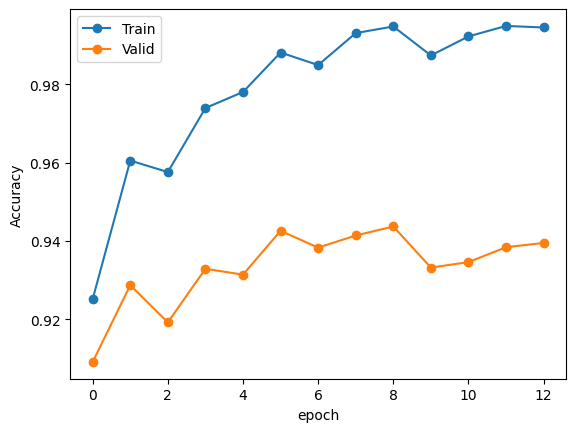

In [24]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32,sampler=ImbalancedDatasetSampler(decisionset))
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.2938460401433437,train_accu=0.8929780896813415
Epoch=0,valid_loss=0.3602857011690893,valid_accu=0.8682634730538922
0
Epoch=1,train_loss=0.1639529051215613,train_accu=0.9459790281121221
Epoch=1,valid_loss=0.2787648381281348,valid_accu=0.9031936127744511
0
Epoch=2,train_loss=0.07828731539345822,train_accu=0.9737647394834551
Epoch=2,valid_loss=0.22737385762248868,valid_accu=0.9222982606216139
0
Epoch=3,train_loss=0.049652201380600273,train_accu=0.9858011342772043
Epoch=3,valid_loss=0.21402920929872782,valid_accu=0.9291417165668663
0
Epoch=4,train_loss=0.03974462351366757,train_accu=0.9871883797788568
Epoch=4,valid_loss=0.23495245510126642,valid_accu=0.9302822925577416
0
Epoch=5,train_loss=0.03498934667161222,train_accu=0.9889020359867804
Epoch=5,valid_loss=0.2629911899168309,valid_accu=0.9237239806102081
Epoch=6,train_loss=0.08077688431466457,train_accu=0.970663837773879
Epoch=6,valid_loss=0.3289032659058132,valid_accu=0.9031936127744511
Epoch=7,train_loss=0.037951626

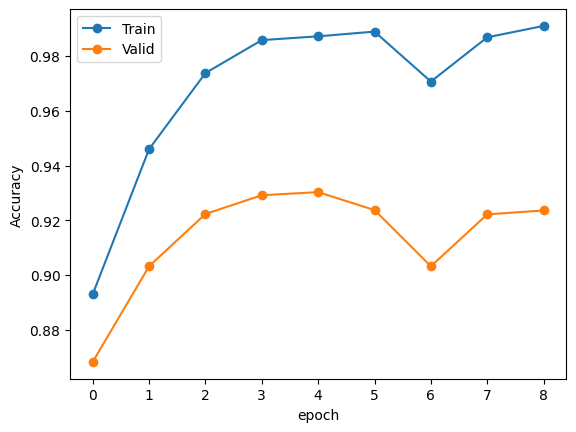

In [25]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_1.pth')

In [26]:
summary(model_T,(3,299,299))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 74, 74]          23,296
              ReLU-2           [-1, 64, 74, 74]               0
         MaxPool2d-3           [-1, 64, 36, 36]               0
            Conv2d-4          [-1, 192, 36, 36]         307,392
              ReLU-5          [-1, 192, 36, 36]               0
         MaxPool2d-6          [-1, 192, 17, 17]               0
            Conv2d-7          [-1, 384, 17, 17]         663,936
              ReLU-8          [-1, 384, 17, 17]               0
            Conv2d-9          [-1, 256, 17, 17]         884,992
             ReLU-10          [-1, 256, 17, 17]               0
           Conv2d-11          [-1, 256, 17, 17]         590,080
             ReLU-12          [-1, 256, 17, 17]               0
        MaxPool2d-13            [-1, 256, 8, 8]               0
AdaptiveAvgPool2d-14            [-1, 25

Epoch=0,train_loss=0.35888072522485825,train_accu=0.8592126584691641
Epoch=0,valid_loss=0.4374195031487375,valid_accu=0.8225050234427328
0
Epoch=1,train_loss=0.2515246960202296,train_accu=0.899342293394338
Epoch=1,valid_loss=0.37433931371477813,valid_accu=0.847622237106497
0
Epoch=2,train_loss=0.15572579497917627,train_accu=0.9489085883137928
Epoch=2,valid_loss=0.3438239281639028,valid_accu=0.8583389149363697
0
Epoch=3,train_loss=0.08917226948461182,train_accu=0.9718806596130016
Epoch=3,valid_loss=0.3710416572970667,valid_accu=0.8673811118553248
0
Epoch=4,train_loss=0.04635650596780518,train_accu=0.9875131064722142
Epoch=4,valid_loss=0.37870006439415144,valid_accu=0.8663764233087743
Epoch=5,train_loss=0.04070125851620739,train_accu=0.9893241826327328
Epoch=5,valid_loss=0.3904834063617639,valid_accu=0.8737441393168118
0
Epoch=6,train_loss=0.05039138423752801,train_accu=0.9861786293013058
Epoch=6,valid_loss=0.42170311142275657,valid_accu=0.8600133958472873
Epoch=7,train_loss=0.0192679939

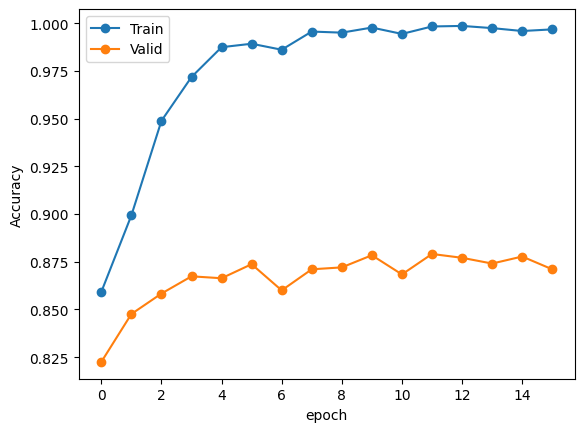

In [27]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
#model_F=torch.load(f'model_{model_algo}_F_0.pth')

In [28]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.021357716484421065, 0.9940285714285715)

In [29]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(0.1839689754921943, 0.9437)

In [30]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.039744623593845896, 0.9871883797788568)

In [31]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.008191782644006725, 0.9983795634353255)

In [32]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.2349524662591196, 0.9302822925577416)

In [33]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(0.48971680026284337, 0.8791024782317481)

In [34]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum

(0.030286959488450418, 0.9905428571428572, 10491)

In [35]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum

(0.3110263213157654, 0.915, 2986)

In [36]:
#全部模型裝在一起的表現
def total_model_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)

            softmax=torch.softmax(out_growth, dim=1)

            out=model_decision(data)
            _, y_pred_tag = torch.max(out, dim = 1)


            for pred,d,t in zip(y_pred_tag,data,target):

                if(pred==0):
                    outputs.append(model_F(d.unsqueeze(0)))
                    sum_F+=1
                else:
                    outputs.append(model_T(d.unsqueeze(0)))
                    sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [37]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.13431772966573813, 0.9855142857142857, 10536, 24464)

In [38]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(1.4007843724787234, 0.8678, 2967, 7033)

In [39]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [40]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.363011,0.878314,0.449855,0.843900
1,Model_Decision,0.021358,0.994029,0.021358,0.943700
2,Model_T,0.039745,0.987188,0.234952,0.930282
3,Model_F,0.008192,0.998380,0.489717,0.879102
4,Total_Model,0.134318,0.985514,1.400784,0.867800
5,Total_Model_without_decision,0.030287,0.990543,0.311026,0.915000


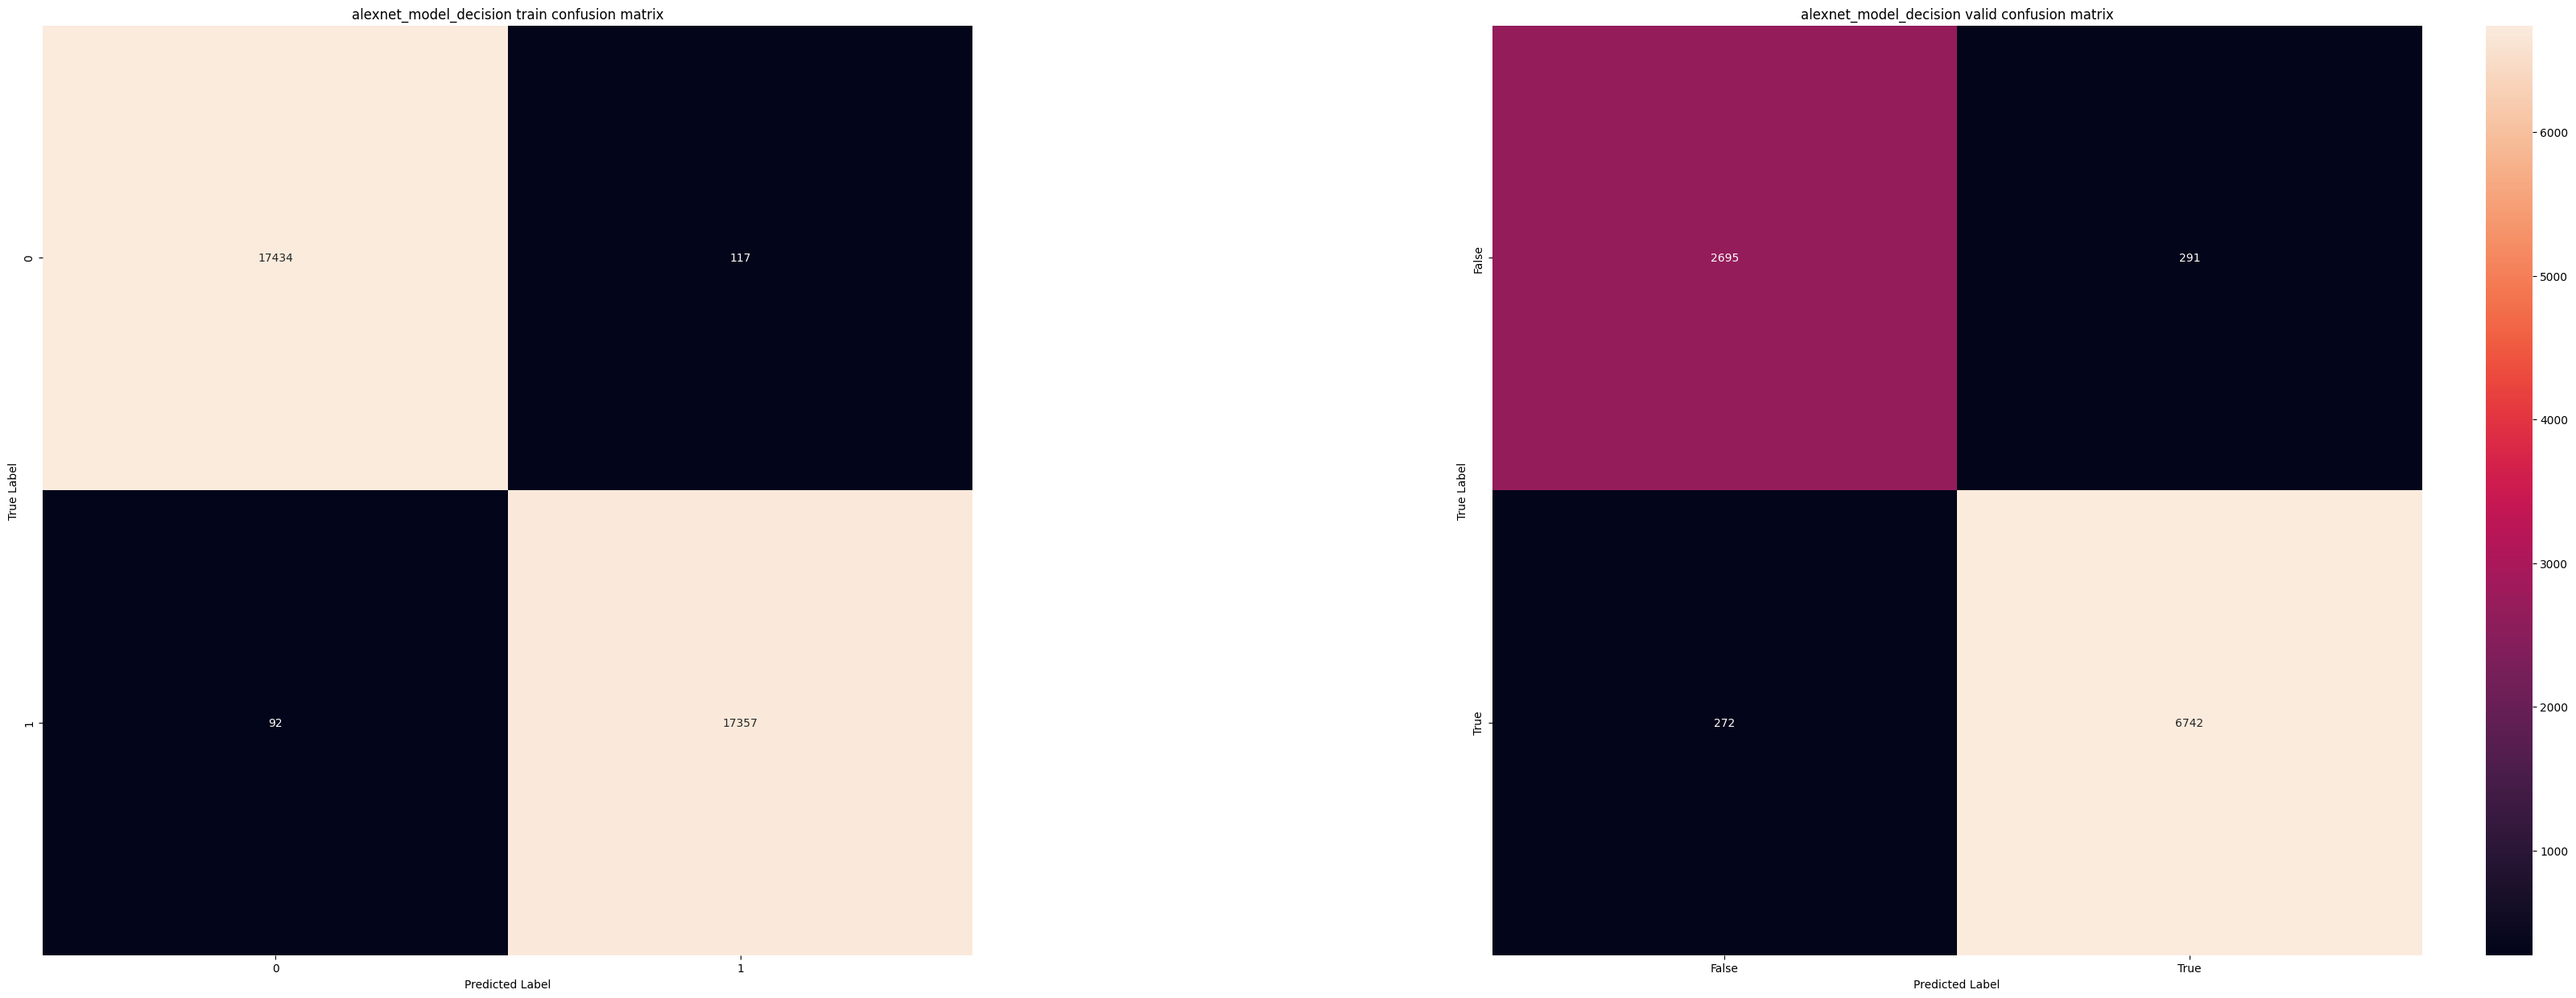

In [41]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

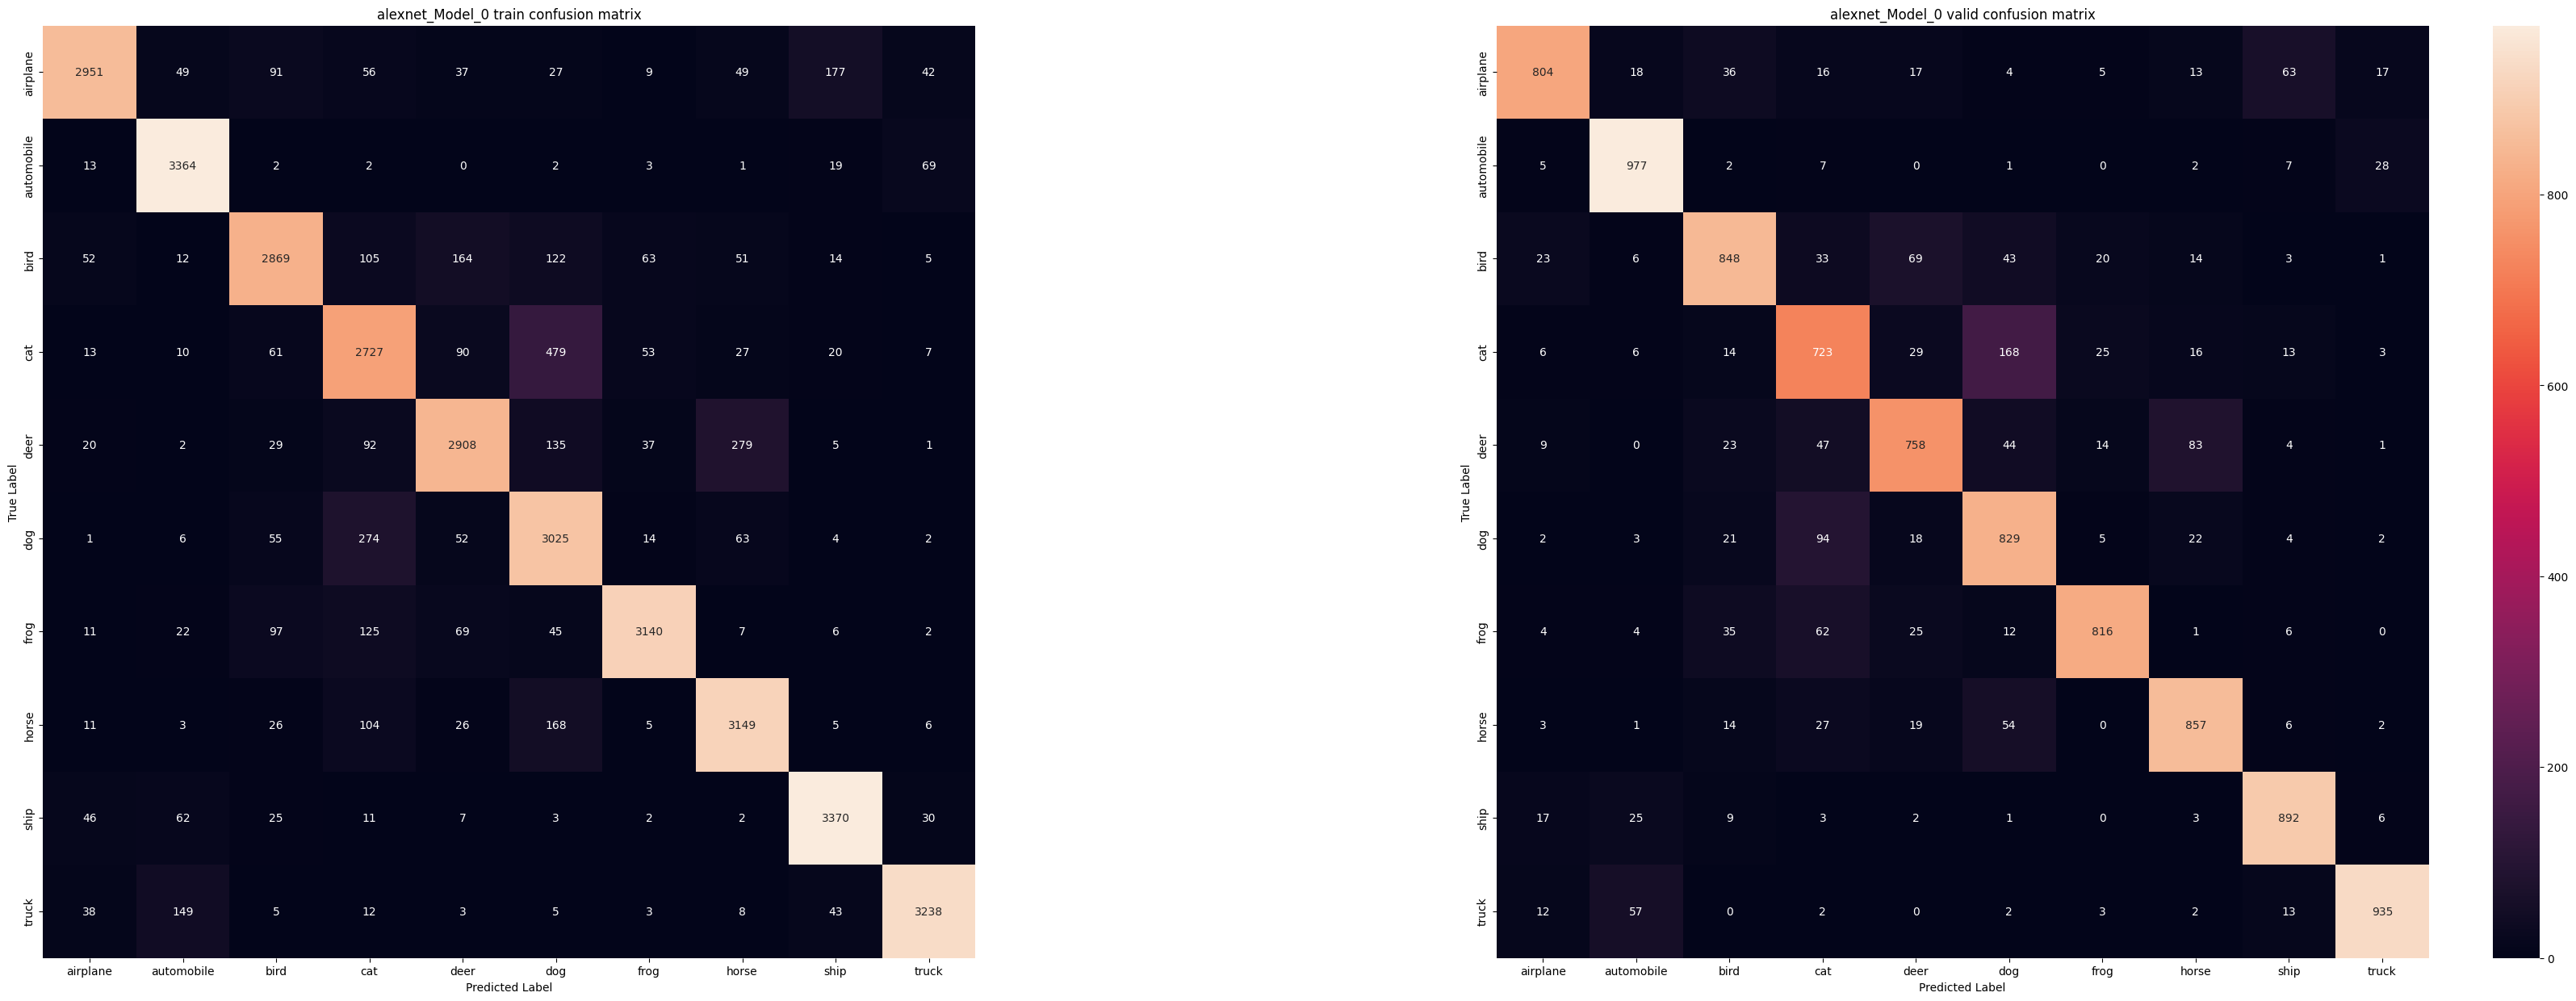

In [42]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

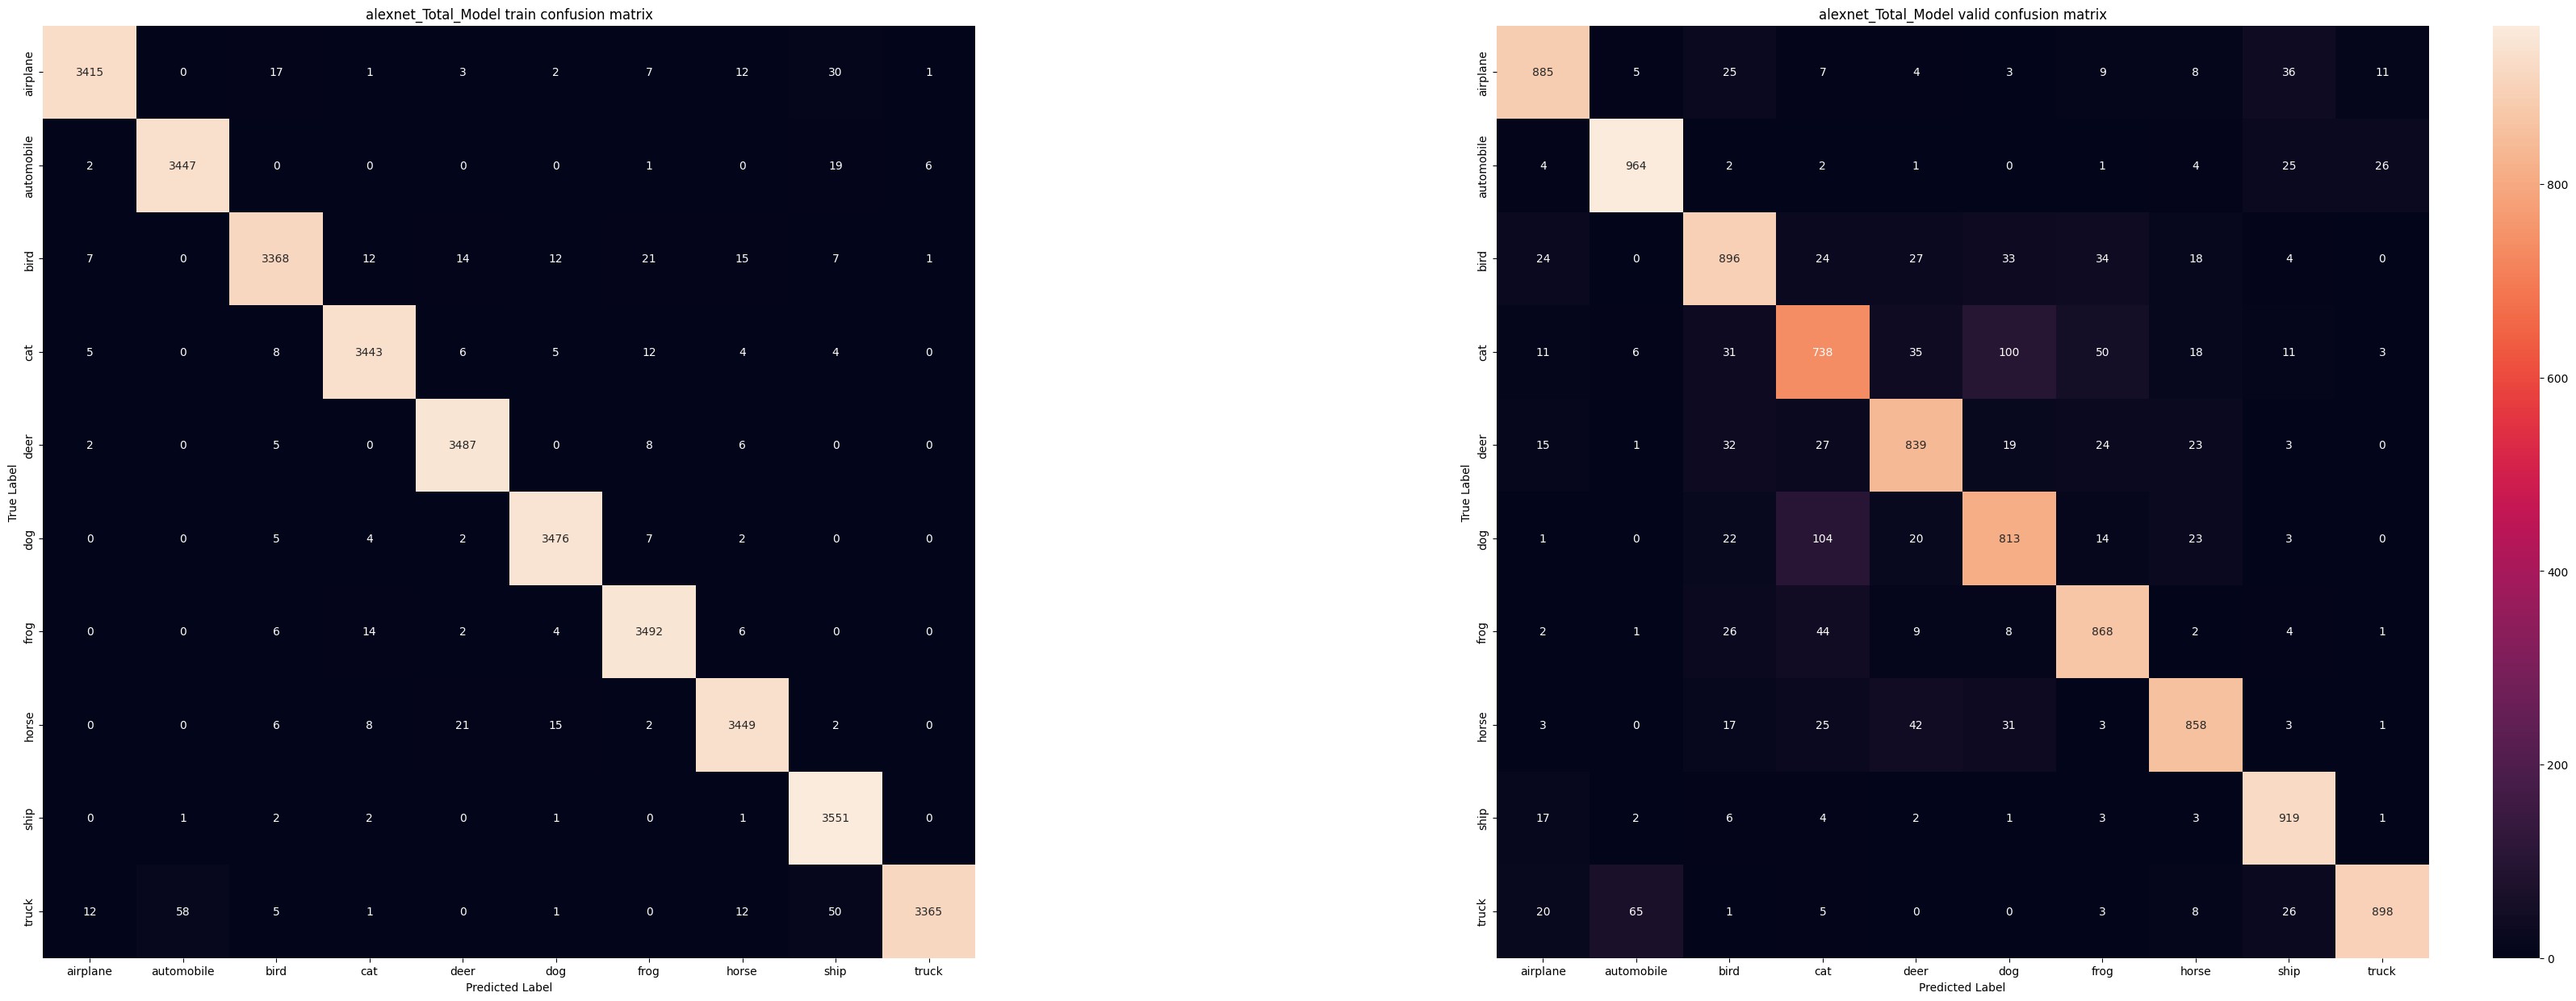

In [43]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

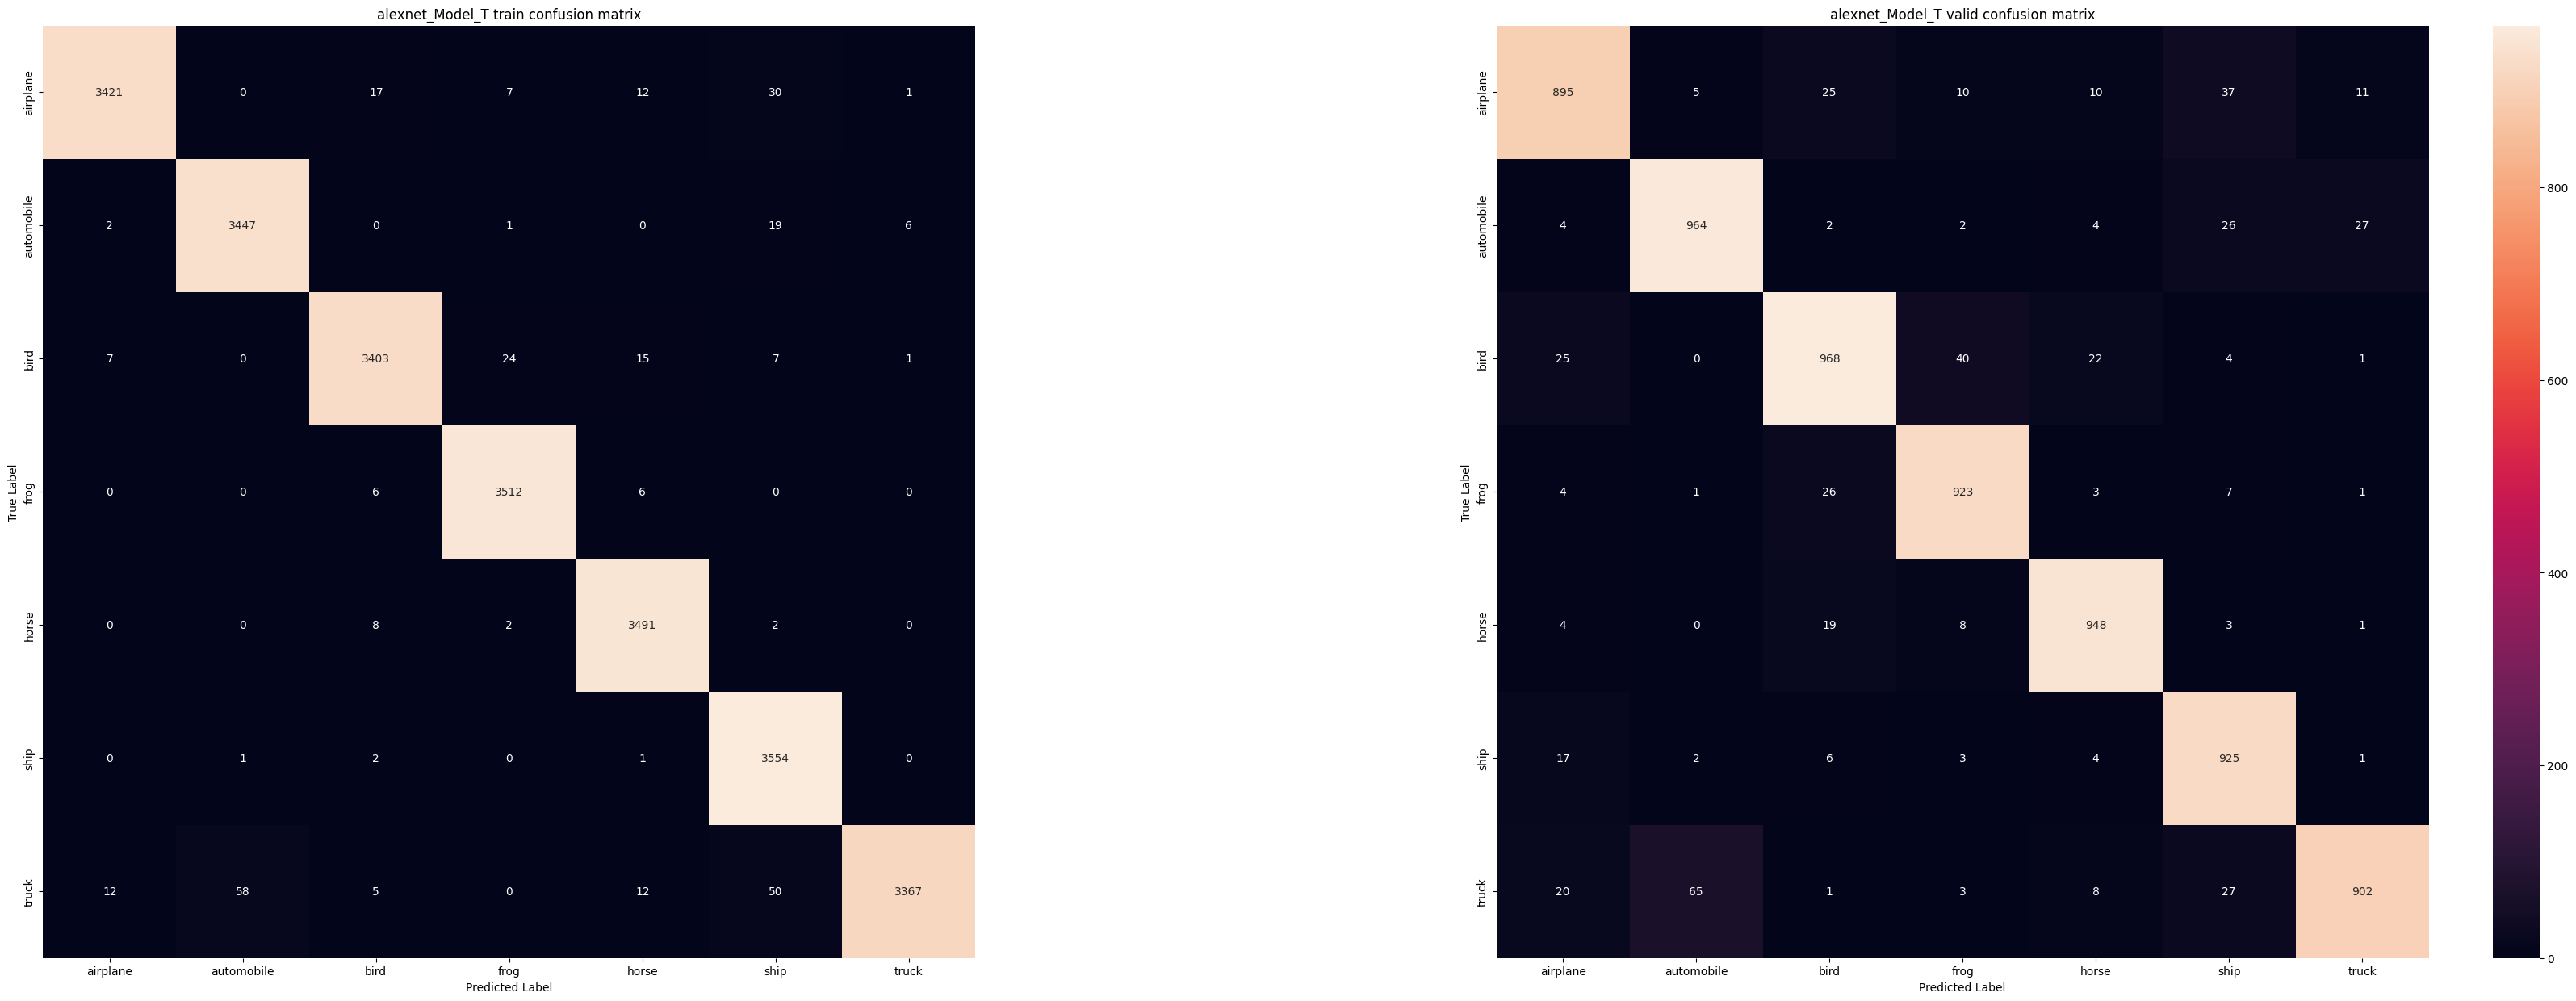

In [44]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

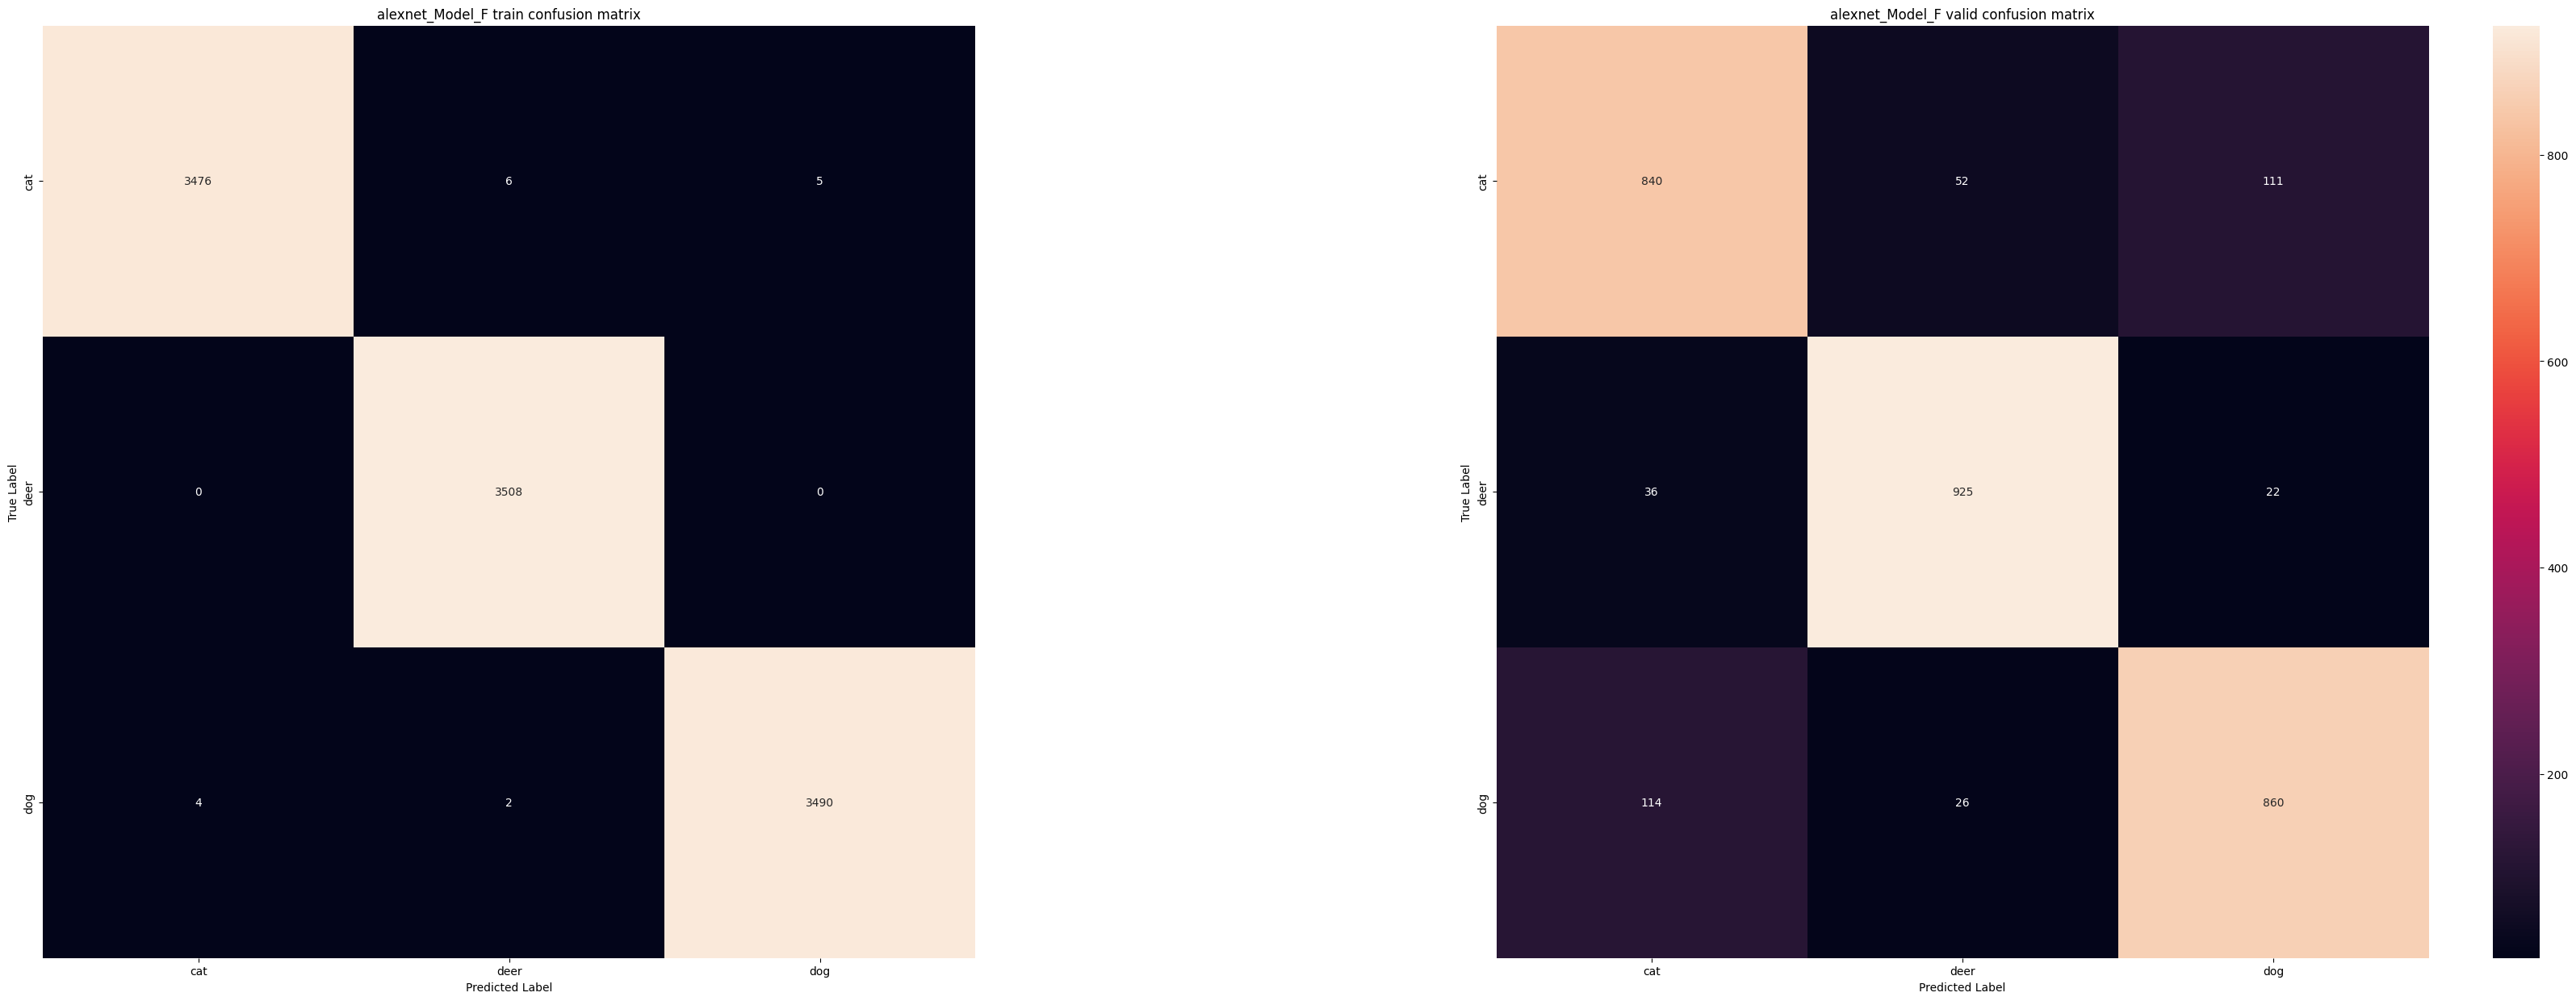

In [45]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [46]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [47]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,9719,7,5,7,7,0.993959,0.999999,0.982271,0.999946,False,True,True,True,True
1,32566,5,5,7,5,1.000000,0.999264,0.962731,0.999817,True,False,True,False,False
2,15132,7,4,7,7,0.989167,1.000000,0.990246,0.999911,False,True,True,True,True
3,24310,9,5,9,9,0.663554,0.999883,0.995756,1.000000,False,True,True,True,True
4,12225,3,3,6,3,1.000000,0.994724,0.907943,0.980522,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34995,21039,2,3,2,2,0.890296,0.999663,0.996009,1.000000,False,True,True,True,True
34996,43537,7,3,7,0,0.830665,0.999992,0.615162,0.995027,False,True,False,True,True
34997,22868,3,3,6,3,1.000000,0.751482,0.991098,0.999138,True,False,True,False,False
34998,3901,2,5,2,5,0.999786,0.993175,0.708096,0.985863,False,True,False,True,True


In [48]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']>df_results['Softmax_T']) & (df_results['flag']==False)])

50

In [49]:
len(df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9) & (df_results['Softmax_F']<df_results['Softmax_T']) & (df_results['flag']==True)])

68

In [50]:
df_results[(df_results['Decision']!=df_results['flag']) & (df_results['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
195,30409,7,5,7,7,0.611683,0.999999,0.790600,0.633163,False,True,True,False,True
213,22726,2,5,2,2,0.918173,0.998799,0.801358,0.658202,False,True,True,False,True
541,8970,4,4,7,7,0.999994,0.913197,0.374494,0.521841,True,False,False,True,False
642,13727,2,3,2,2,0.679731,0.997822,0.794583,0.502036,False,True,True,False,True
857,45080,6,5,6,3,0.908522,0.999875,0.426762,0.530929,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33436,36133,7,4,7,7,0.993881,0.999985,0.963041,0.872972,False,True,True,False,True
33777,21260,4,4,2,4,0.999990,0.885995,0.647890,0.558236,True,False,True,True,False
33850,39421,7,5,7,7,0.920308,0.999979,0.904099,0.698979,False,True,True,False,True
34435,25008,3,3,0,3,0.999998,0.410664,0.897016,0.503001,True,False,True,True,False


In [51]:
df_results[(df_results['Decision']!=df_results['flag'])]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
195,30409,7,5,7,7,0.611683,0.999999,0.790600,0.633163,False,True,True,False,True
213,22726,2,5,2,2,0.918173,0.998799,0.801358,0.658202,False,True,True,False,True
541,8970,4,4,7,7,0.999994,0.913197,0.374494,0.521841,True,False,False,True,False
642,13727,2,3,2,2,0.679731,0.997822,0.794583,0.502036,False,True,True,False,True
857,45080,6,5,6,3,0.908522,0.999875,0.426762,0.530929,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33777,21260,4,4,2,4,0.999990,0.885995,0.647890,0.558236,True,False,True,True,False
33850,39421,7,5,7,7,0.920308,0.999979,0.904099,0.698979,False,True,True,False,True
34435,25008,3,3,0,3,0.999998,0.410664,0.897016,0.503001,True,False,True,True,False
34489,40371,2,4,2,5,0.857961,0.997546,0.490179,0.727611,False,True,False,False,True


In [52]:
df_results_v=show_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F)
df_results_v

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,28708,2,3,6,6,0.559745,0.821625,0.518554,0.826051,False,False,False,True,True
1,42958,1,3,1,1,0.996560,0.996927,0.971757,1.000000,False,True,True,True,True
2,40219,4,4,7,4,1.000000,0.651007,0.929191,0.999978,True,False,True,False,False
3,9897,3,3,7,3,0.999999,0.821728,0.838824,1.000000,True,False,True,False,False
4,16639,6,3,6,3,0.996196,0.999935,0.586081,0.999998,False,True,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,17032,1,3,1,1,1.000000,0.965153,0.742393,1.000000,False,True,True,True,True
9996,48557,0,4,0,0,0.999707,0.999257,0.873072,1.000000,False,True,True,True,True
9997,5499,9,3,9,9,0.977543,0.999622,0.999458,1.000000,False,True,True,True,True
9998,21981,2,4,2,4,0.876284,0.995065,0.352969,0.996813,False,True,False,True,True


In [53]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']>df_results_v['Softmax_T']) & (df_results_v['flag']==False)])

112

In [54]:
len(df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9) & (df_results_v['Softmax_F']<df_results_v['Softmax_T']) & (df_results_v['flag']==True)])

69

In [55]:
df_results_v[(df_results_v['Decision']!=df_results_v['flag']) & (df_results_v['Softmax_decision']<0.9)]

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
143,34230,6,3,6,5,0.680117,0.578478,0.328130,0.548678,False,True,False,False,True
157,36738,3,3,1,3,0.930712,0.618954,0.391996,0.762065,True,False,True,True,False
209,47406,7,3,7,3,0.999997,0.912809,0.911021,0.693576,False,True,False,False,True
235,154,6,4,6,6,0.651508,0.995743,0.559731,0.817941,False,True,True,False,True
240,7257,6,3,8,3,0.811782,0.627082,0.266361,0.527420,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9841,15335,3,3,6,6,0.999999,0.992009,0.653471,0.819172,True,False,False,True,False
9909,25952,7,5,7,5,0.999139,0.662874,0.576068,0.828425,False,True,False,False,True
9928,31326,7,5,7,5,0.754005,0.998467,0.480795,0.753327,False,True,False,False,True
9947,25584,7,3,6,3,0.982576,0.457288,0.454143,0.744870,False,False,False,False,True


In [56]:
#全部模型裝在一起的表現
def total_model_combine_evaluate(data_dl,size,model_0,model_T,model_F,model_decision):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)

         
            
            for s0,st,sf,d in zip(softmax_0,softmax_T,softmax_F,data):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(softmax_decision<0.9):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1
                else:
                   
                    if(pred==0):
                        outputs.append(model_F(d.unsqueeze(0)))
                        sum_F+=1
                    else:
                        outputs.append(model_T(d.unsqueeze(0)))
                        sum_T+=1

            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [57]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(0.2339593604103396, 0.9826285714285714, 10643, 24357)

In [58]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_combine_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_loss,accu,sum_F,sum_T

(1.4810194414883853, 0.872, 3044, 6956)